In [1]:
# --- Imports & Config ---
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import seaborn as sns
import matplotlib.pyplot as plt

# Paths
DATA_DIR = Path("../data")
RAW_DIR = DATA_DIR / "raw"
PROC_DIR = DATA_DIR / "processed"

# File paths
TRAIN_PATH = RAW_DIR / "claims_train.csv"

# Schema (central config for feature logic)
SCHEMA = {
    "targets": {"nb": "ClaimNb", "rate": "ClaimRate"},
    "exposure": "Exposure",
    "ordered_area": ['A','B','C','D','E','F'],
    "bonus_bins": ([0, 100, 150, 200, np.inf], ["bonus","mild_malus","malus","heavy_malus"]),
    "driv_bins":  ([17, 25, 35, 50, 65, 120], ["18-25","26-35","36-50","51-65","65+"]),
    "vehage_bins": ([-1, 2, 5, 10, np.inf], ["0-2","3-5","6-10","10+"]),
    "vehpower_q": 4,
}


In [2]:
# --- Feature Engineering ---
df = pd.read_csv(TRAIN_PATH)
df.columns = df.columns.str.strip()

class FeatureRules(BaseEstimator, TransformerMixin):
    def __init__(self, schema):
        self.s = schema
        self.area_map = {a: i+1 for i,a in enumerate(schema["ordered_area"])}

    def transform(self, X):
        X = X.copy()
        df["Exposure"] = df["Exposure"].clip(upper=1.0)
        X["Density_log1p"] = np.log1p(X["Density"])
        X["BonusMalus_bin"] = pd.cut(X["BonusMalus"], *self.s["bonus_bins"], include_lowest=True)
        X["DrivAge_bin"] = pd.cut(X["DrivAge"], *self.s["driv_bins"], include_lowest=True)
        X["VehAge_bin"] = pd.cut(X["VehAge"], *self.s["vehage_bins"], include_lowest=True)
        X["VehPower_rank"] = X["VehPower"].rank(method="average")
        X["VehPower_bin"] = pd.qcut(X["VehPower"], q=self.s["vehpower_q"], labels=[f"q{i+1}" for i in range(self.s["vehpower_q"])])
        X["Area_ord"] = X["Area"].map(self.area_map)
        X["VehGas_bin"] = (X["VehGas"] == "Diesel").astype(int)
        return X

rules = FeatureRules(SCHEMA)
df_feat = rules.transform(df)
df_feat.head()

,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region,Density_log1p,BonusMalus_bin,DrivAge_bin,VehAge_bin,VehPower_rank,VehPower_bin,Area_ord,VehGas_bin
0,2122523.0,0,0.43,D,7,18,36,95,B1,Regular,1054,R24,6.961296,"(-0.001, 100.0]","(35.0, 50.0]","(10.0, inf]",369654.5,q3,4,0
1,3173420.0,0,0.10,D,7,17,80,95,B2,Regular,598,R25,6.395262,"(-0.001, 100.0]","(65.0, 120.0]","(10.0, inf]",369654.5,q3,4,0
2,1188619.0,0,0.33,E,7,3,36,76,B6,Regular,4172,R82,8.336390,"(-0.001, 100.0]","(35.0, 50.0]","(2.0, 5.0]",369654.5,q3,5,0
3,31400.0,0,0.56,A,5,4,73,52,B13,Diesel,15,R24,2.772589,"(-0.001, 100.0]","(65.0, 120.0]","(2.0, 5.0]",142334.0,q1,1,1
4,3138755.0,0,0.27,E,8,0,37,50,B11,Diesel,3021,R53,8.013674,"(-0.001, 100.0]","(35.0, 50.0]","(-1.001, 2.0]",446509.0,q4,5,1


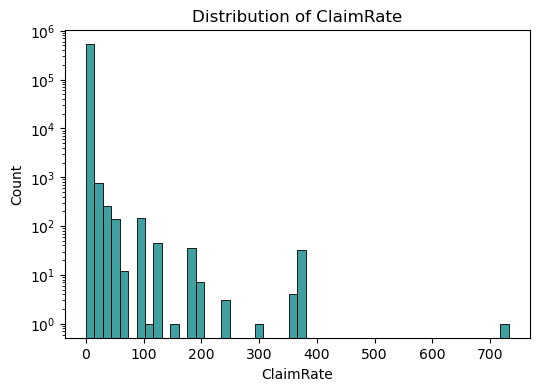

In [3]:
df_feat["ClaimRate"] = df_feat["ClaimNb"] / df_feat["Exposure"]
df_feat["ClaimRate"].describe()

plt.figure(figsize=(6,4))
sns.histplot(df_feat["ClaimRate"], bins=50, color="teal")
plt.title("Distribution of ClaimRate")
plt.xlabel("ClaimRate")
plt.ylabel("Count")
plt.yscale("log")
plt.show()

In [4]:
# --- Feature Validation ---
cols_to_check = ["VehPower_rank", "VehPower_bin", "VehGas_bin", "Area_ord", "BonusMalus_bin", "DrivAge_bin", "VehAge_bin"]
print(df_feat[cols_to_check].head())

# Count per bin (to verify distribution)
for col in ["BonusMalus_bin","DrivAge_bin","VehAge_bin","VehPower_bin"]:
    print(f"\n{col} value counts:")
    print(df_feat[col].value_counts())

   VehPower_rank VehPower_bin  VehGas_bin  Area_ord   BonusMalus_bin  \
0       369654.5           q3           0         4  (-0.001, 100.0]   
1       369654.5           q3           0         4  (-0.001, 100.0]   
2       369654.5           q3           0         5  (-0.001, 100.0]   
3       142334.0           q1           1         1  (-0.001, 100.0]   
4       446509.0           q4           1         5  (-0.001, 100.0]   

     DrivAge_bin     VehAge_bin  
0   (35.0, 50.0]    (10.0, inf]  
1  (65.0, 120.0]    (10.0, inf]  
2   (35.0, 50.0]     (2.0, 5.0]  
3  (65.0, 120.0]     (2.0, 5.0]  
4   (35.0, 50.0]  (-1.001, 2.0]  

BonusMalus_bin value counts:
BonusMalus_bin
(-0.001, 100.0]    536172
(100.0, 150.0]       6071
(150.0, 200.0]        163
(200.0, inf]            4
Name: count, dtype: int64

DrivAge_bin value counts:
DrivAge_bin
(35.0, 50.0]      201471
(50.0, 65.0]      136980
(25.0, 35.0]      119237
(65.0, 120.0]      53626
(16.999, 25.0]     31096
Name: count, dtype: int6

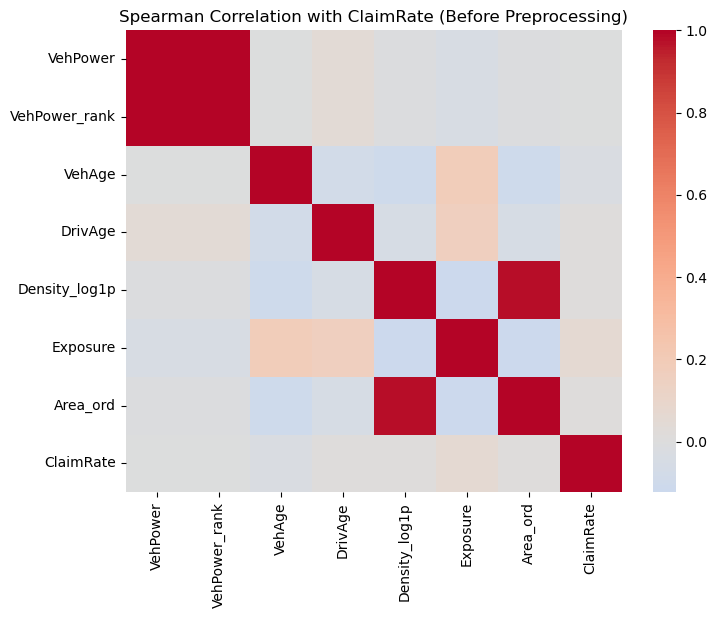

In [5]:
# --- Feature Selection ---
def exists(cols, df_): return [c for c in cols if c in df_.columns]

num_features = exists(["VehPower","VehPower_rank","VehAge","DrivAge","Density_log1p","Exposure","Area_ord"], df_feat)
cat_features = exists(["VehBrand","VehGas_bin","BonusMalus_bin","DrivAge_bin","VehAge_bin","VehPower_bin","Region"], df_feat)

# Correlation heatmap
corr = df_feat[num_features + ["ClaimRate"]].corr(method="spearman")
plt.figure(figsize=(8,6))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Spearman Correlation with ClaimRate (Before Preprocessing)")
plt.show()

In [6]:
# --- Preprocessing ---
preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imp", SimpleImputer(strategy="mean")),
            ("sc", StandardScaler())
        ]), num_features),
        ("cat", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False))
        ]), cat_features)
    ]
)

X_processed = preprocess.fit_transform(df_feat[num_features + cat_features])

# Extract final feature names
ohe = preprocess.named_transformers_["cat"].named_steps["ohe"]
feature_names = num_features + ohe.get_feature_names_out(cat_features).tolist()
print(f"Number of features: {len(feature_names)}")

X_processed_df = pd.DataFrame(X_processed, columns=feature_names)

Number of features: 52


C:\Users\onadi\AppData\Local\Temp\ipykernel_30628\2563604537.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


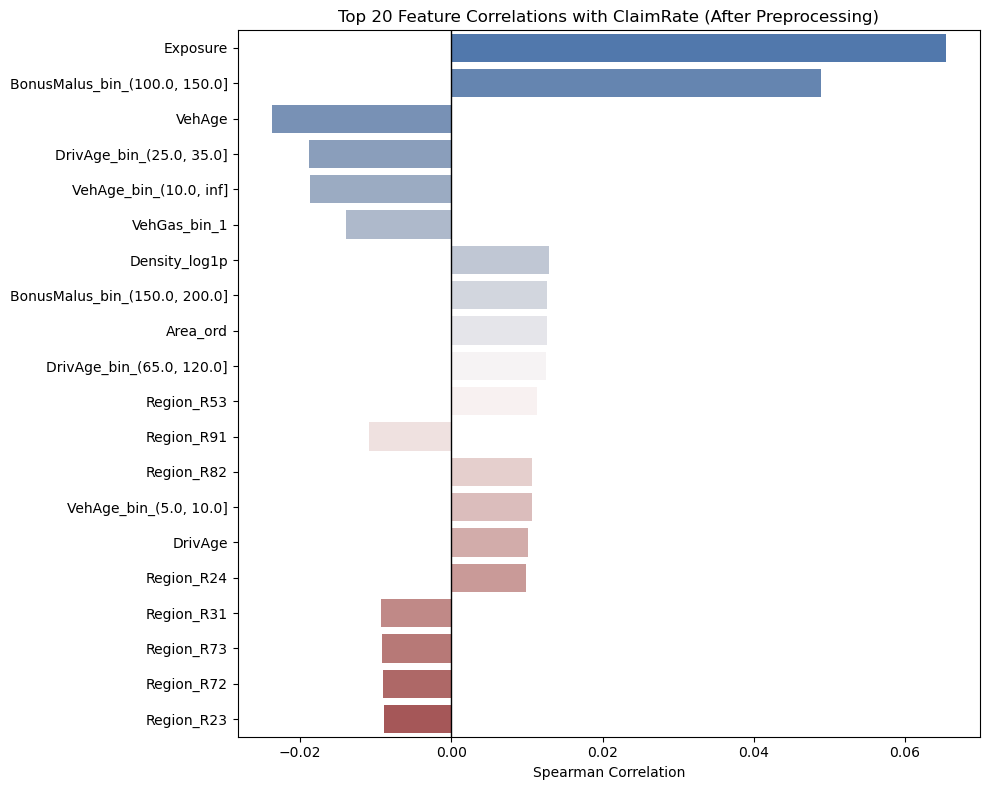

In [7]:
corr_df = pd.concat([X_processed_df, df_feat[["ClaimRate"]].reset_index(drop=True)], axis=1)
corrs = corr_df.corr(method="spearman")["ClaimRate"].drop("ClaimRate")

corrs_sorted = corrs.reindex(corrs.abs().sort_values(ascending=False).index)

plt.figure(figsize=(10, 8))
sns.barplot(
    y=corrs_sorted.index[:20],
    x=corrs_sorted.values[:20],
    palette="vlag"
)
plt.title("Top 20 Feature Correlations with ClaimRate (After Preprocessing)")
plt.xlabel("Spearman Correlation")
plt.ylabel("")
plt.axvline(0, color="black", lw=1)
plt.tight_layout()
plt.show()

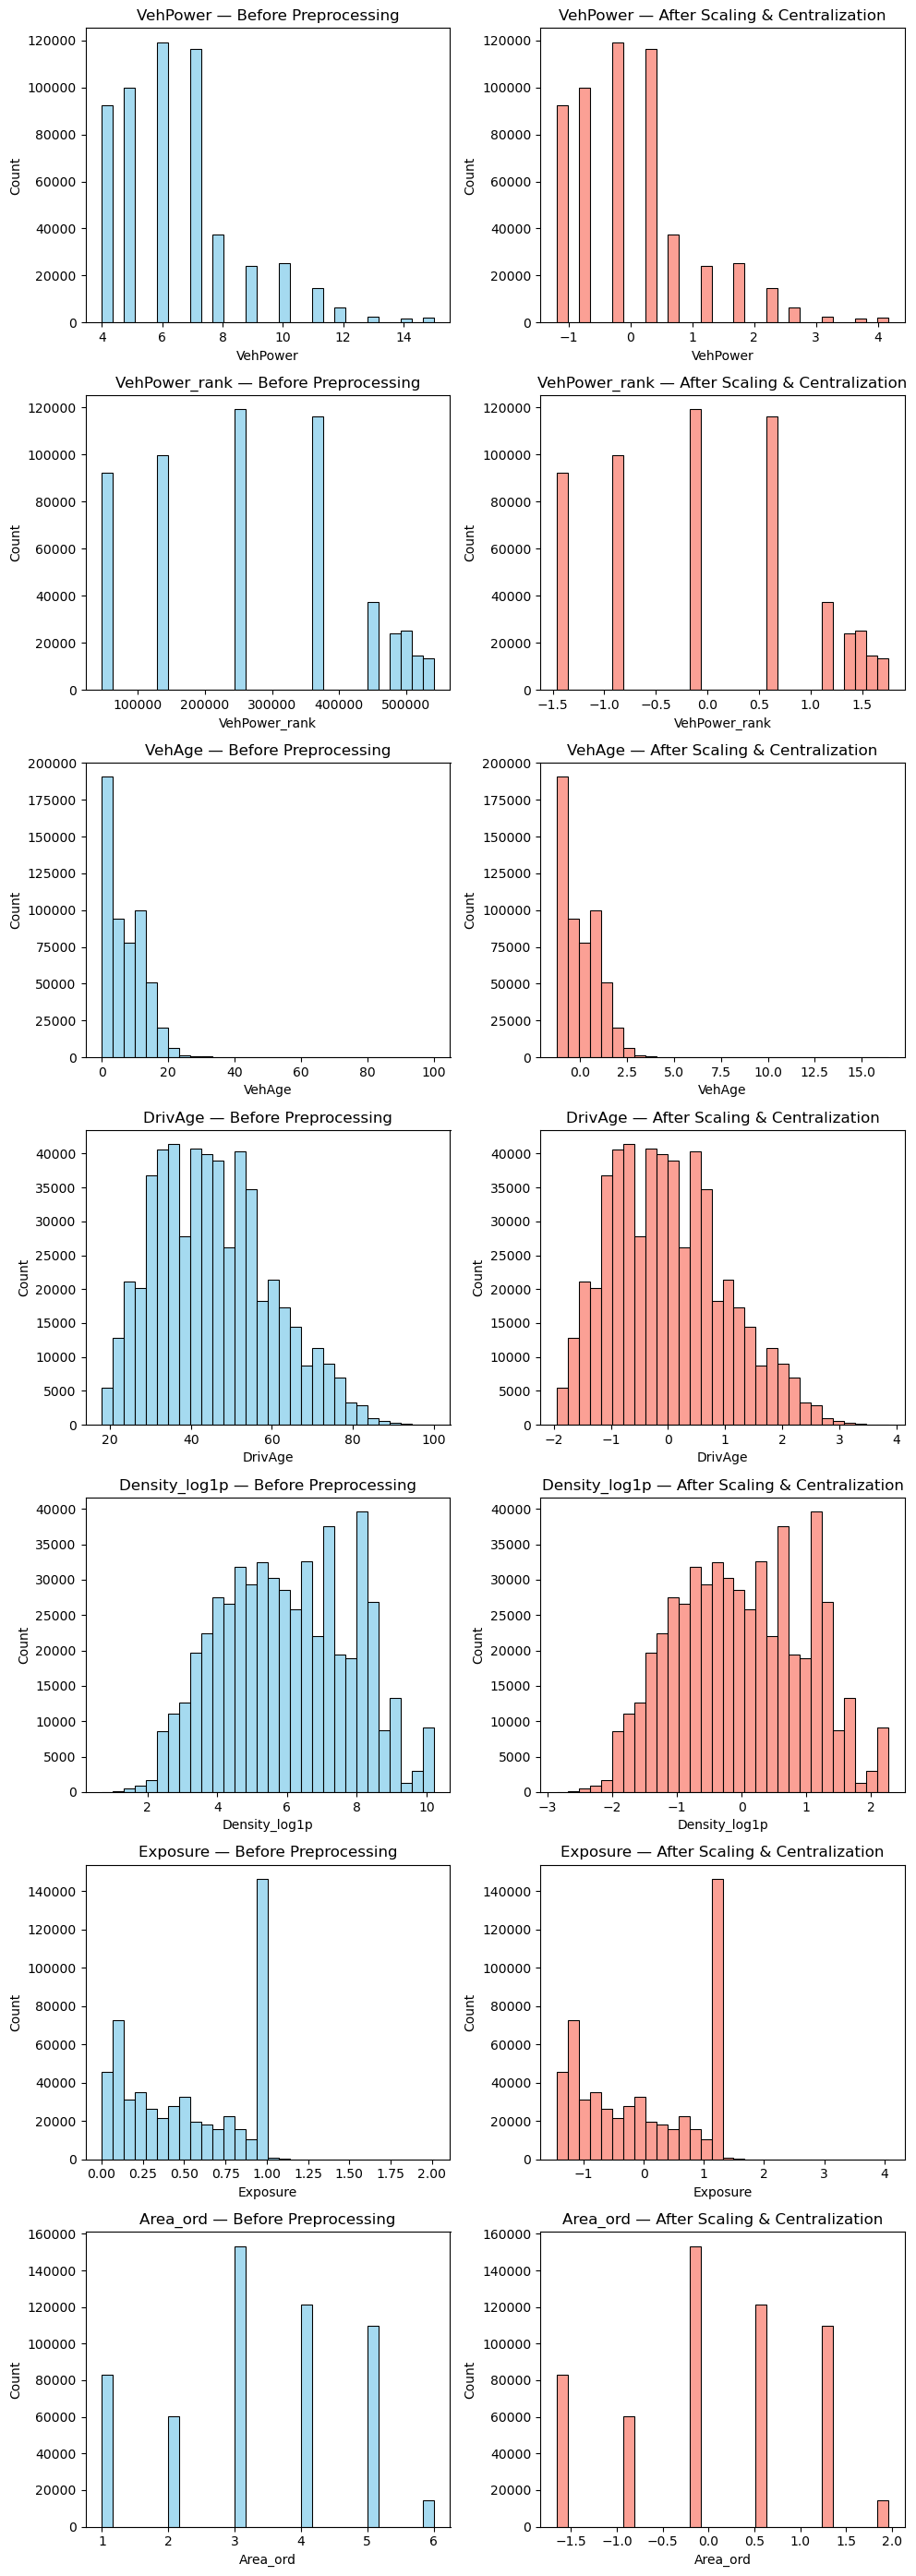

In [8]:
# number of numeric features we actually scaled
n_feats = len(num_features)
fig, axes = plt.subplots(n_feats, 2, figsize=(10, 4 * n_feats))

for i, feature in enumerate(num_features):
    # before preprocessing
    sns.histplot(df_feat[feature], bins=30, ax=axes[i, 0], color="skyblue", kde=False)
    axes[i, 0].set_title(f"{feature} — Before Preprocessing")

    # after preprocessing (will exist since num_features passed through pipeline)
    sns.histplot(X_processed_df[feature], bins=30, ax=axes[i, 1], color="salmon", kde=False)
    axes[i, 1].set_title(f"{feature} — After Scaling & Centralization")

plt.tight_layout()
plt.show()

In [9]:
PROC_DIR.mkdir(exist_ok=True, parents=True)

base_cols = [SCHEMA["targets"]["nb"], SCHEMA["targets"]["rate"]]
meta = df_feat[base_cols].reset_index(drop=True)

processed_full = pd.concat([meta, X_processed_df], axis=1)

nb_cols = [SCHEMA["targets"]["nb"]] + feature_names
rate_cols = [SCHEMA["targets"]["rate"]] + feature_names

processed_full[nb_cols].to_csv(PROC_DIR / "features_claimnb.csv", index=False)
processed_full[rate_cols].to_csv(PROC_DIR / "features_claimrate.csv", index=False)